In [1]:
import boto3
import pandas as pd
import seaborn as sns

s3 = boto3.client("s3")
files = s3.list_objects_v2(Bucket="dsan6000-am5030", Prefix="wikipedia-hourly/")["Contents"]

df = pd.read_parquet("s3://dsan6000-am5030/wikipedia-hourly/")
# df = pd.DataFrame()
# for file in files:
#     if file["Key"].endswith(".parquet"):
#         obj = s3.get_object(Bucket="dsan6000-am5030", Key=file["Key"])
#         df = pd.concat([df, pd.read_parquet(obj["Body"])], ignore_index=True)

print(df.head())
df["datetime"] = pd.to_datetime(df["datetime"])


              datetime                        $schema  \
0  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
1  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
2  2026-09-01 04:00:01  /mediawiki/recentchange/1.0.0   
3  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
4  2026-09-01 04:00:03  /mediawiki/recentchange/1.0.0   

                                                meta            id  type  \
0  {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   
1  {'uri': 'https://en.wikipedia.org/wiki/Beverid...  2.063884e+09  edit   
2  {'uri': 'https://en.wikipedia.org/wiki/1920_Un...  2.063884e+09  edit   
3  {'uri': 'https://en.wikipedia.org/wiki/1987_Ae...  2.063884e+09  edit   
4  {'uri': 'https://en.wikipedia.org/wiki/Marvin_...  2.063884e+09  edit   

   namespace                                              title  \
0          0                                     Jake O'Donnell   
1          0                                    Beveridge Award   

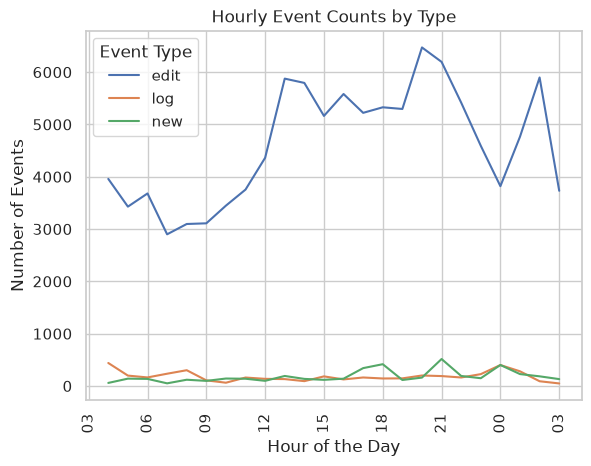

In [16]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# plot one
hourly = df.groupby(pd.Grouper(key="datetime", freq="h")).size()
ax = sns.lineplot(data=hourly)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))   
plt.xticks(rotation=90) 
ax.set_title("Total Number of Events per Hour")
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Number of Events")
plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")


# plot two
plt.clf()
by_type = (
    df.groupby([pd.Grouper(key="datetime", freq="h"), "type"])
      .size()
      .reset_index(name="count")
)
ax = sns.lineplot(data=by_type, x="datetime", y="count", hue="type")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
plt.xticks(rotation=90)
ax.set_title("Hourly Event Counts by Type")
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Number of Events")
ax.legend(title="Event Type")
plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")
